In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("../../Data/titanic_Dataset.csv",usecols=['Age','Fare','Survived'])
df

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500
...,...,...,...
886,0,27.0,13.0000
887,1,19.0,30.0000
888,0,NaN,23.4500
889,1,26.0,30.0000


In [6]:
df.dropna(inplace=True)

In [7]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.iloc[:,1:],df.iloc[:,0], test_size=0.2, random_state=42)

In [8]:
X_train

,Age,Fare
328,31.0,20.5250
73,26.0,14.4542
253,30.0,16.1000
719,33.0,7.7750
666,25.0,13.0000
...,...,...
92,46.0,61.1750
134,25.0,13.0000
337,41.0,134.5000
548,33.0,20.5250


In [11]:
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.compose import ColumnTransformer

binning_encoder = ColumnTransformer(transformers=[
    ("age_encod", KBinsDiscretizer(encode='ordinal', n_bins=10, strategy='uniform'),['Age']),
    ("fare_encod", KBinsDiscretizer(encode='ordinal', n_bins=10, strategy='uniform'), ['Fare'])
])

In [12]:
X_train_encod = binning_encoder.fit_transform(X_train)
X_test_encod = binning_encoder.transform(X_test)

In [16]:
pd.DataFrame(X_train_encod, columns=X_train.columns)['Age'].value_counts()

Age
2.0    142
3.0    136
4.0     91
5.0     59
0.0     46
6.0     36
1.0     31
7.0     19
8.0      9
9.0      2
Name: count, dtype: int64

In [17]:
pd.DataFrame(X_train_encod, columns=X_train.columns)['Fare'].value_counts()

Fare
0.0    456
1.0     74
2.0     24
4.0      8
5.0      6
3.0      2
9.0      1
Name: count, dtype: int64

# Without binning

In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

In [26]:
def modelTest(X_train, X_test, y_train, y_test, model, cv=10):
    model_obj = model
    model_obj.fit(X_train, y_train)
    y_pred = model_obj.predict(X_test)
    
    X = pd.concat([X_train, X_test])
    y = pd.concat([y_train, y_test])
    return accuracy_score(y_test, y_pred), np.mean(cross_val_score(estimator=model,X=X,y=y,cv=cv))


In [27]:
modelTest(X_train,X_test,y_train,y_test,LogisticRegression())

(0.6293706293706294, np.float64(0.6511932707355242))

In [28]:
from sklearn.tree import DecisionTreeClassifier
modelTest(X_train, X_test, y_train, y_test, DecisionTreeClassifier())

(0.6293706293706294, np.float64(0.6387519561815336))

# using Binning

In [30]:
modelTest(pd.DataFrame(X_train_encod, columns=X_train.columns), pd.DataFrame(X_test_encod, columns=X_test.columns), y_train, y_test, LogisticRegression())

(0.6713286713286714, np.float64(0.6652190923317685))

In [31]:
modelTest(pd.DataFrame(X_train_encod, columns=X_train.columns), pd.DataFrame(X_test_encod, columns=X_test.columns), y_train, y_test, DecisionTreeClassifier())

(0.6783216783216783, np.float64(0.6875586854460093))

In [42]:
def applyDifferentBinning(nbins, strategy, model):
    binning_encoder = ColumnTransformer(transformers=[
        ("age_encod", KBinsDiscretizer(encode='ordinal', n_bins=nbins, strategy=strategy), ['Age']),
        ("fare_encod", KBinsDiscretizer(encode='ordinal', n_bins=nbins, strategy=strategy), ['Fare'])
    ])

    X_train_encod = binning_encoder.fit_transform(X_train)
    X_test_encod = binning_encoder.transform(X_test)
    
    plt.figure(figsize=(16,12))
    plt.subplot(221)
    plt.hist(X_train['Age'], color="green")
    plt.title("Age without Binning")
    
    plt.subplot(222)
    plt.hist(X_train_encod[:,0], color="red")
    plt.title("Age Binning")
    
    plt.subplot(223)
    plt.hist(X_train['Fare'], color="purple")
    plt.title("Fare without Binning")
    
    plt.subplot(224)
    plt.hist(X_train_encod[:,1], color="blue")
    plt.title("Fare Binning")
    
    return modelTest(pd.DataFrame(X_train_encod, columns=X_train.columns), pd.DataFrame(X_test_encod, columns=X_test.columns), y_train, y_test, model)
    

(0.6713286713286714, np.float64(0.6652190923317685))

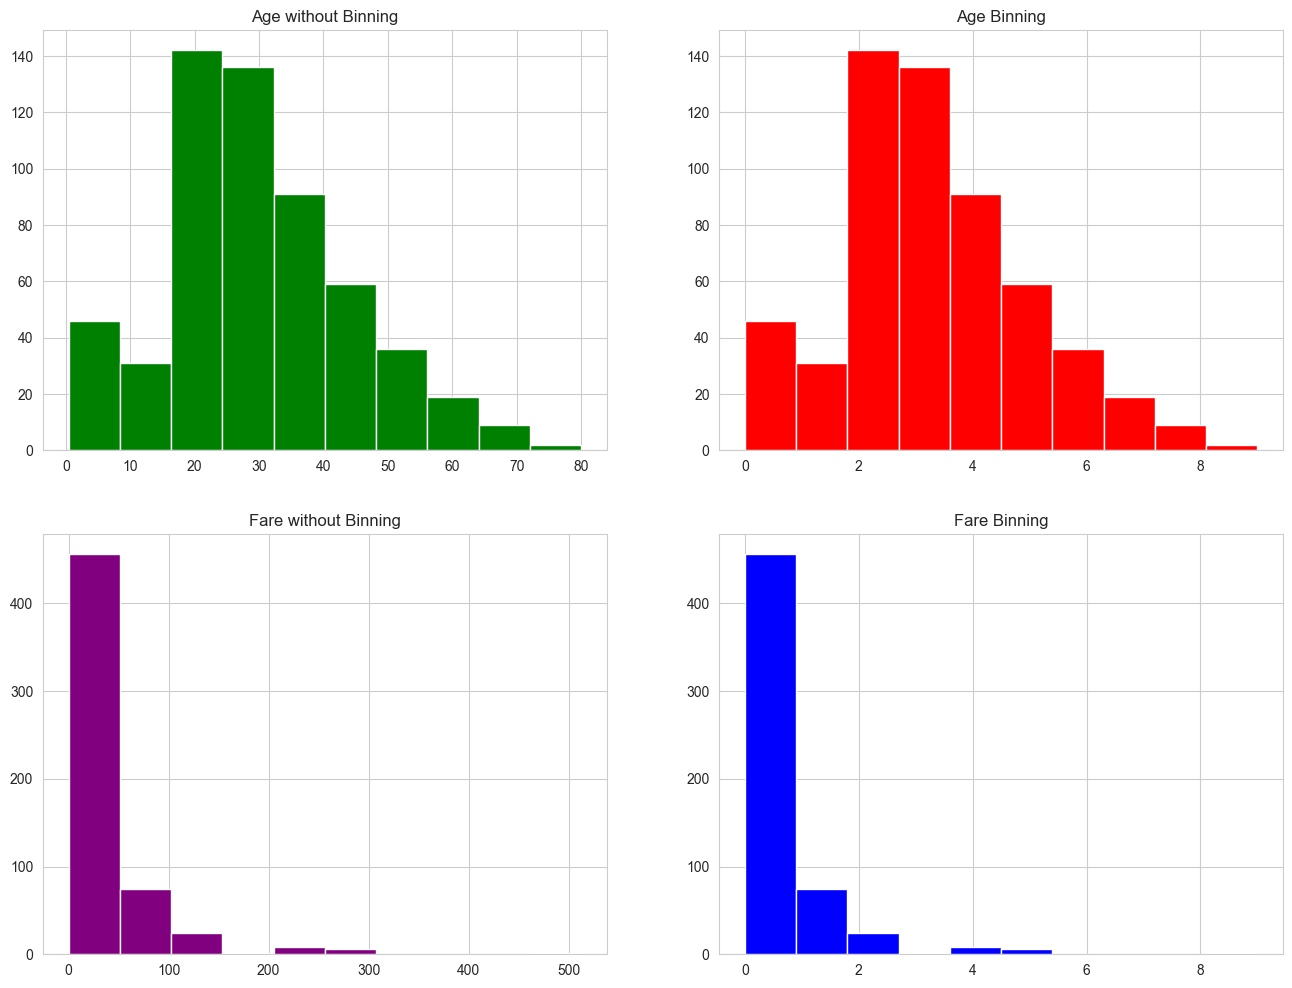

In [43]:
applyDifferentBinning(10,"uniform", LogisticRegression())

(0.6783216783216783, np.float64(0.6875586854460093))

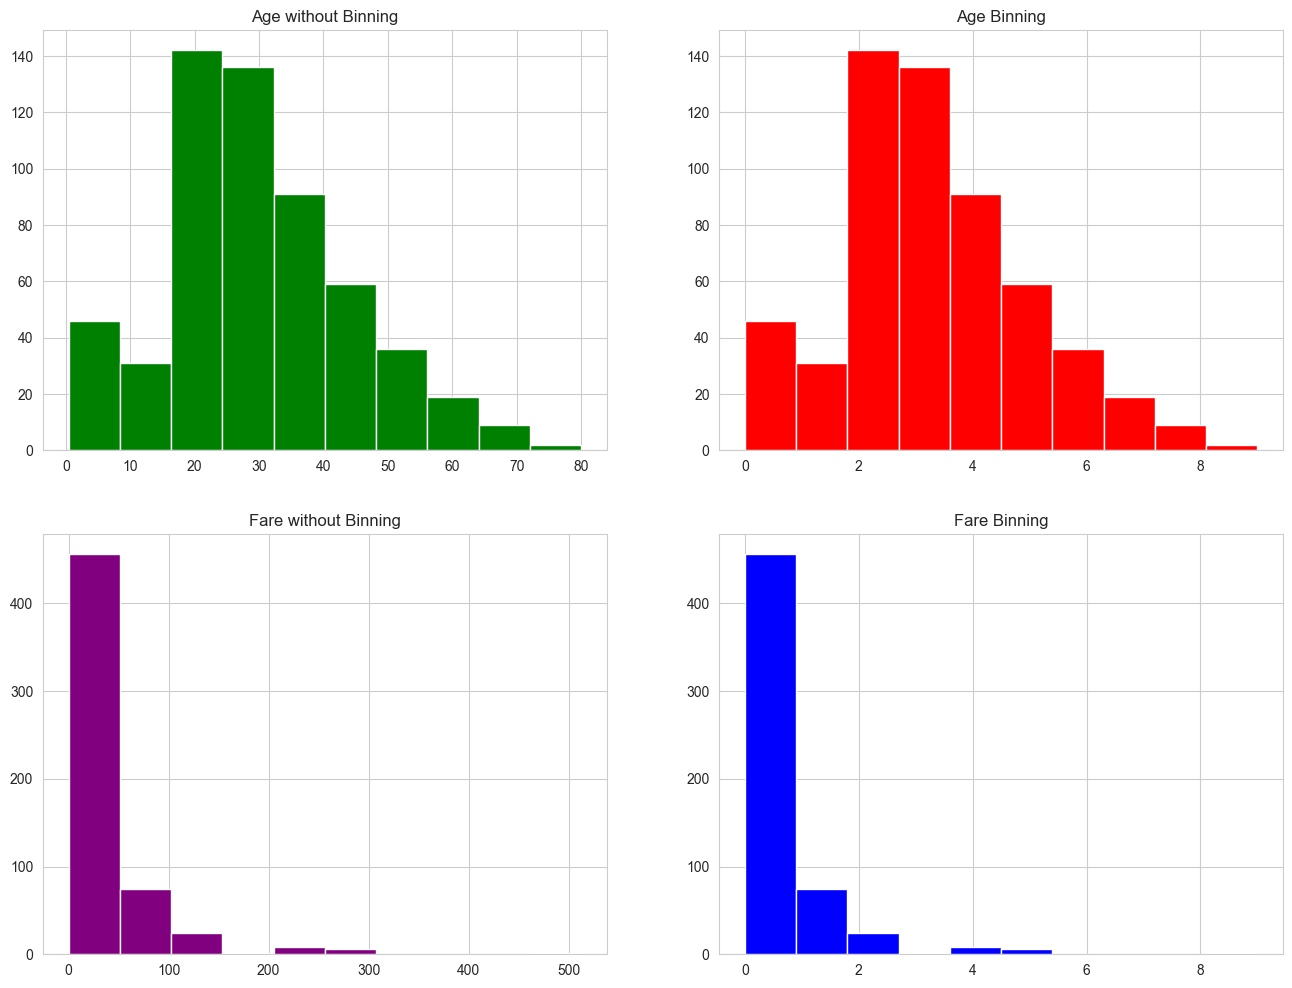

In [44]:
applyDifferentBinning(10,"uniform", DecisionTreeClassifier())

F:\Data_Science\Machine_Learning\MachineTrain_Lab\.venv\Lib\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
F:\Data_Science\Machine_Learning\MachineTrain_Lab\.venv\Lib\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


(0.6153846153846154, np.float64(0.6637910798122065))

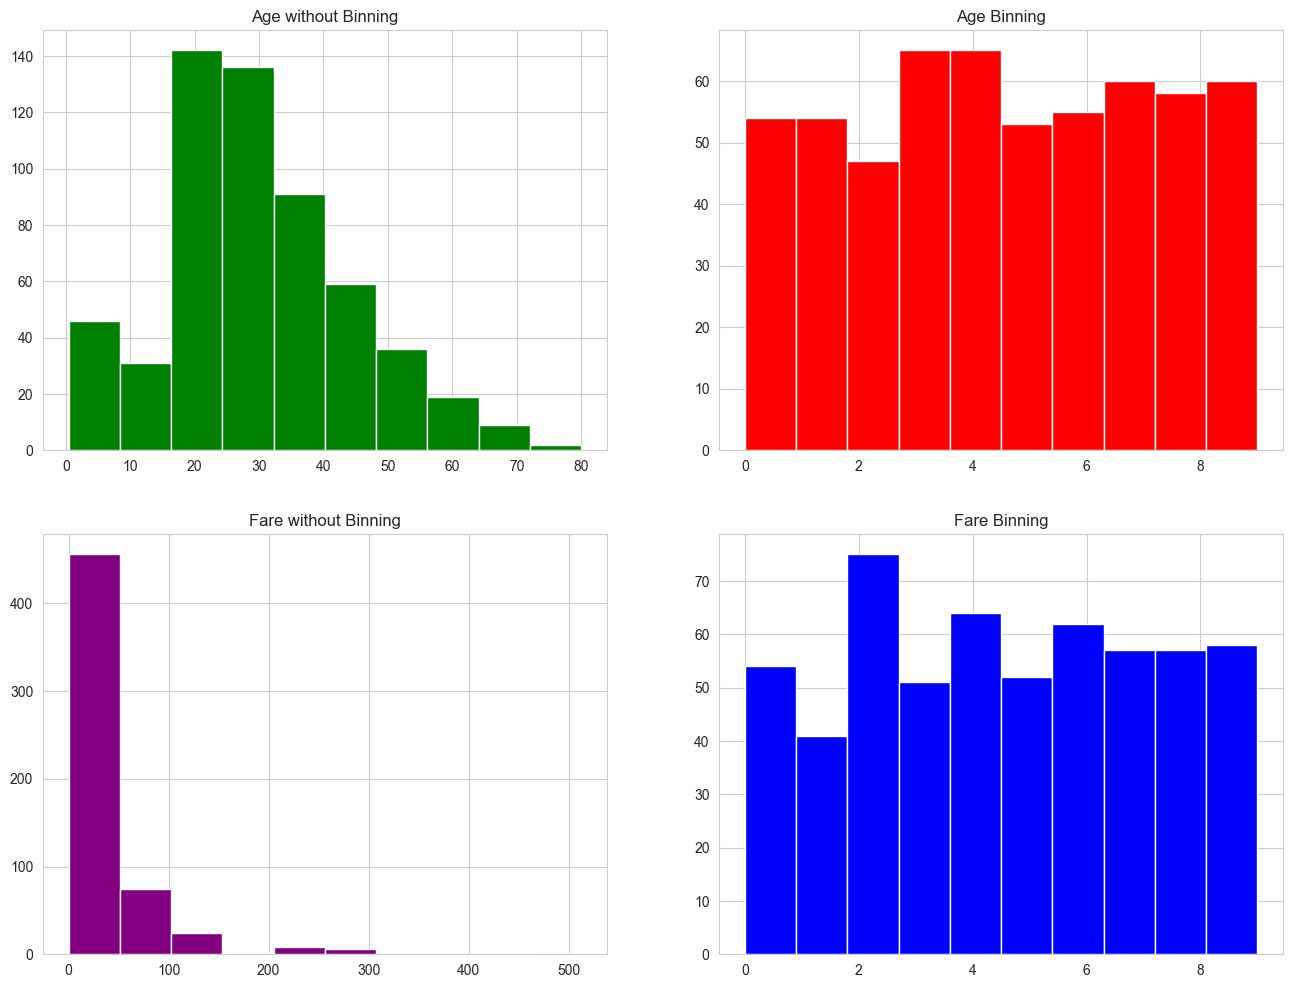

In [45]:
applyDifferentBinning(10,"quantile", LogisticRegression())

(0.6153846153846154, np.float64(0.665160406885759))

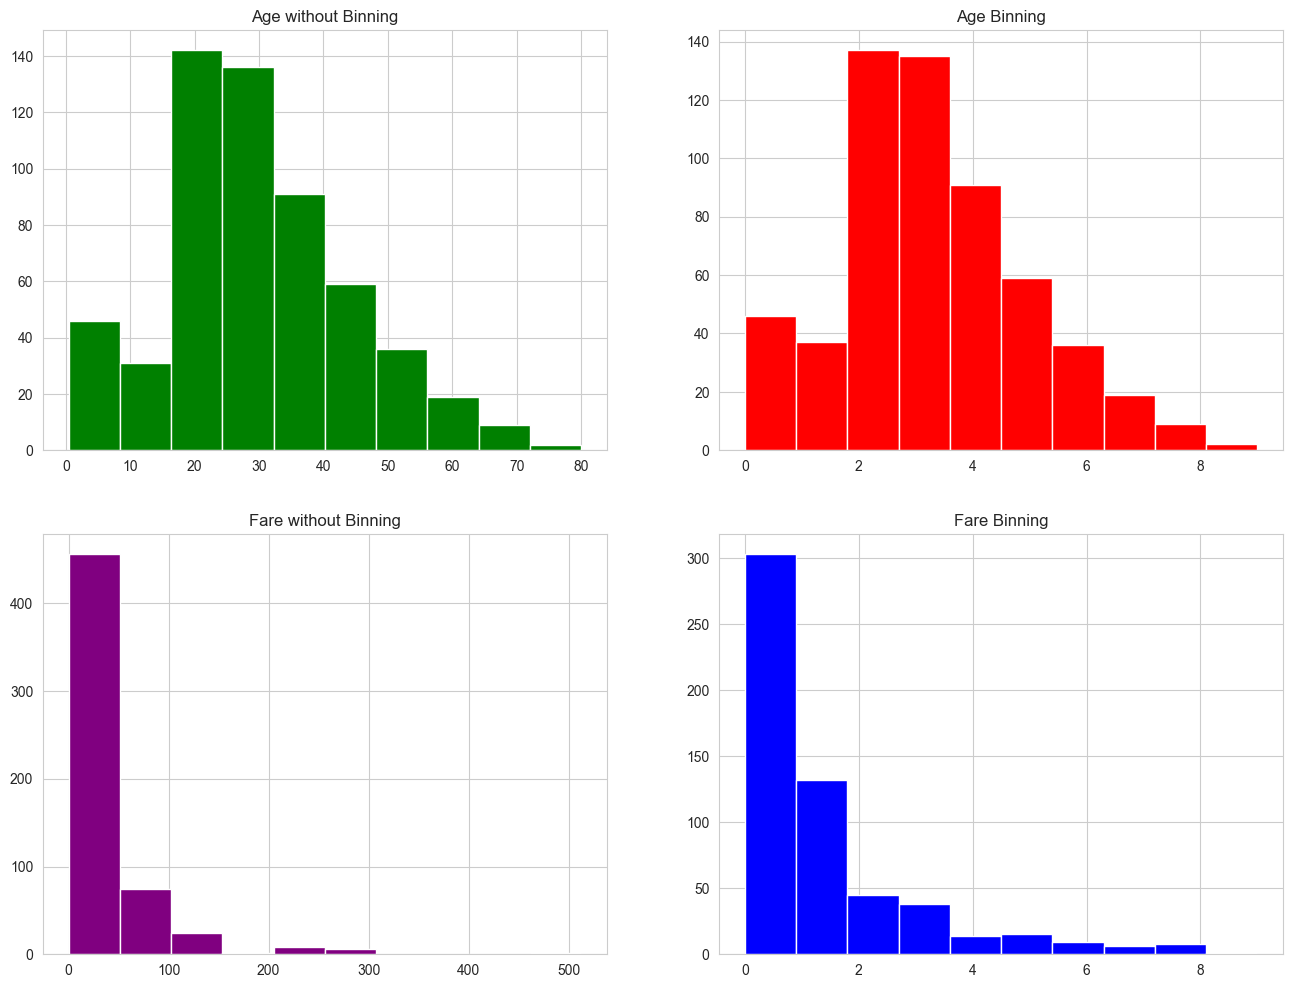

In [46]:
applyDifferentBinning(10,"kmeans", LogisticRegression())